#Problem Statement:
Hotel booking cancellations significantly impact revenue management and operational planning in the hospitality industry. Frequent cancellations lead to revenue loss, inefficient room allocation, and increased operational costs.

The objective of this project is to analyze booking data from INN Hotels Group to:
- Identify key factors influencing booking cancellations.
- Understand customer behavior patterns.
- Perform exploratory data analysis (EDA) to extract meaningful insights.
- Prepare the data for building predictive classification models.

The target variable is **booking_status**, which indicates a booking is canceled or not.

#Import Libraries

In [ ]:
#Basic libraries
import numpy as np
import pandas as pd

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocessing & Model Building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

#Evaluaion Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

#Set style
sns.set(style = 'whitegrid')

###Observation:
The required libraries for data manipulation, visualization, and machine learning have been successfully imported.
- Libraries such as NumPy and Pandas will be used for handling and processing the dataset.
- Matplotlib and Seaborn will assist in creating visualizations for exploratory data analysis.
- Scikit-learn modules have been imported to perform data splitting, preprocessing, and implementation of classificaion models such as Logistic Regression, Decision Tree, Random Forest, and K-Nearest Neighbors.
- Evaluation metrics like accuracy score, confusion matrix, and classification report will be used to assess model performance.
- Warnings have been suppressed to ensure cleaner output during execution.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/INNHotelsGroup.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###Observation:
The Google Drive has been successfully mounted, and the dataset (INNHotelsGroup.csv) has been loaded into the dataframe df.

#Exploratory Data Analysis
##Checking the structure of Data

In [ ]:
print(df.head())

  Booking_ID  no_of_adults  no_of_children  no_of_weekend_nights  \
0   INN00001             2               0                     1   
1   INN00002             2               0                     2   
2   INN00003             1               0                     2   
3   INN00004             2               0                     0   
4   INN00005             2               0                     1   

   no_of_week_nights type_of_meal_plan  required_car_parking_space  \
0                  2       Meal Plan 1                           0   
1                  3      Not Selected                           0   
2                  1       Meal Plan 1                           0   
3                  2       Meal Plan 1                           0   
4                  1      Not Selected                           0   

  room_type_reserved  lead_time  arrival_year  arrival_month  arrival_date  \
0        Room_Type 1        224          2017             10             2   
1        Room_

###Observation:
The dataset shows individual booking records with features like number of guests, stay duration, meal plan, room type, and pricing. Initial rows indicate most bookings have 1-2 adults, no children, and low special requests. Both canceled and non-canceled bookings are present, confirming the classification objective. The data appears organized with a mix of categorical and numerical variables.

In [ ]:
print(df.tail())

      Booking_ID  no_of_adults  no_of_children  no_of_weekend_nights  \
36270   INN36271             3               0                     2   
36271   INN36272             2               0                     1   
36272   INN36273             2               0                     2   
36273   INN36274             2               0                     0   
36274   INN36275             2               0                     1   

       no_of_week_nights type_of_meal_plan  required_car_parking_space  \
36270                  6       Meal Plan 1                           0   
36271                  3       Meal Plan 1                           0   
36272                  6       Meal Plan 1                           0   
36273                  3      Not Selected                           0   
36274                  2       Meal Plan 1                           0   

      room_type_reserved  lead_time  arrival_year  arrival_month  \
36270        Room_Type 4         85          2018     

###Observation:
The last few records show similar patterns as the initial rows, confirming consistency across the dataset. Most bookings include 2-3 adults, no children, and low special requests. Both online and offline market segments are present. Lead time and room prices vary significantly, indicating diverse booking behavior. The presence of both canceled and non-canceled bookings is observed here as well.

In [ ]:
print(df.shape)

(36275, 19)


###Observation:
The dataset contains 36,275 records and 19 features, indicating a sufficiently large dataset for performing exploratory data analysis and building reliable classification models.

In [ ]:
print(df.columns)

Index(['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status'],
      dtype='object')


###Observation:
The dataset consists of 19 features, including both numerical and categorical variables related to customer details, booking behavior, and pricing. The presence of the target variable **booking_status** confirms that the dataset is suitable for a classification problem.

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

###Observation:
The dataset contains 36,275 entries with no missing values, indicating clean data. It includes a mix of numerical (int64, float64) and categorical (object) variables. Most features are numerical, while key categorical variables include meal plan, room type, market segment, and booking status. The data types are appropriate for further analysis and modeling.

In [ ]:
print(df.isnull().sum())

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64


###Observation:
There are no missing values in any of the features, indicating that the dataset is complete and does not require any imputation or missing value treatment before analysis.

##Checking Data Types of Columns

In [ ]:
print(df.dtypes)

Booking_ID                               object
no_of_adults                              int64
no_of_children                            int64
no_of_weekend_nights                      int64
no_of_week_nights                         int64
type_of_meal_plan                        object
required_car_parking_space                int64
room_type_reserved                       object
lead_time                                 int64
arrival_year                              int64
arrival_month                             int64
arrival_date                              int64
market_segment_type                      object
repeated_guest                            int64
no_of_previous_cancellations              int64
no_of_previous_bookings_not_canceled      int64
avg_price_per_room                      float64
no_of_special_requests                    int64
booking_status                           object
dtype: object


###Observation:
The dataset contains a mix of data types, including numerical variables (int64 and float64) and categorical variables (object). Key categorical features such as meal plan, room type, market segment, and booking status will require encoding for model building, while numerical features are ready for analysis.

##Checking Statistical Summary



In [ ]:
print(df.describe())

       no_of_adults  no_of_children  no_of_weekend_nights  no_of_week_nights  \
count  36275.000000    36275.000000          36275.000000       36275.000000   
mean       1.844962        0.105279              0.810724           2.204300   
std        0.518715        0.402648              0.870644           1.410905   
min        0.000000        0.000000              0.000000           0.000000   
25%        2.000000        0.000000              0.000000           1.000000   
50%        2.000000        0.000000              1.000000           2.000000   
75%        2.000000        0.000000              2.000000           3.000000   
max        4.000000       10.000000              7.000000          17.000000   

       required_car_parking_space     lead_time  arrival_year  arrival_month  \
count                36275.000000  36275.000000  36275.000000   36275.000000   
mean                     0.030986     85.232557   2017.820427       7.423653   
std                      0.173281     8

###Observation:
- The dataset shows that most bookings involve small groups, with an average of around 1-2 adults and very few children, indicating typical individual or couple stays.
- The number of weekend and week nights is generally low, suggesting short-duration stays are more common, though a few longer stays are present.
- The lead time has wide range (0 to 433 days), indicating that bookings are made both very early and at the last minute, reflecting varied customer planning behavior.
- The average room price is approximately €103, with a wide range up to €540, highlighting significant variation in pricing and possible differences across room types or demand periods.
- The proportion of repeated guests is very low, suggesting that most bookings come from new customers rather than loyal returning guests.
- Previous cancellations and previous successful bookings are minimal for most customers, indicating limited prior booking history.
- The number of special requests is generally low, with most customers making 0-1 requests, suggesting limited customization in bookings.

##Check for and treat (if needed) data irregularities

In [ ]:
#Checking for duplicate records
print(df.duplicated().sum())

0


###Observation:
There are no duplicate records present in the dataset, as the duplicate count is 0. This indicates that the data is clean with respect to duplication, and no further preprocessing is required for removing duplicate entries.

In [ ]:
#Checking for logical inconsistencies

print("Children without adults:", df[(df['no_of_adults'] == 0) & (df['no_of_children'] > 0)].shape[0])

print("Zero total nights:", df[(df['no_of_weekend_nights'] == 0) & (df['no_of_week_nights'] == 0)].shape[0])

print("Zero or negative price:", df[df['avg_price_per_room'] <=0].shape[0])

print("Negative lead time:", df[df['lead_time'] < 0].shape[0])

print("High special requests (>5):", df[df['no_of_special_requests'] > 5].shape[0])

Children without adults: 139
Zero total nights: 78
Zero or negative price: 545
Negative lead time: 0
High special requests (>5): 0


###Observation:
- A small number of records (139) show children without adults, which may indicate data entry issues or special booking cases.
- There are 78 bookings with zero total nights, which is logically inconsistent and may need to be hanles or investigated further.
- 545 entries have zero or negative room prices, which is unrealistic and suggests potential data quality issues.
- No negative values are observed in lead time, indicating consistency in booking timelines.
- No unusually high values are found for special requests, suggesting this feature is within a reasonable range.

In [ ]:
#Checking for invalid or unrealistic values

#Negative value check
print((df[['lead_time', 'avg_price_per_room',
           'no_of_adults', 'no_of_children',
           'no_of_weekend_nights', 'no_of_week_nights']] < 0).sum())

#Extreme range verification
print(df[['lead_time', 'avg_price_per_room',
          'no_of_weekend_nights', 'no_of_week_nights',
          'no_of_special_requests']].describe())

lead_time               0
avg_price_per_room      0
no_of_adults            0
no_of_children          0
no_of_weekend_nights    0
no_of_week_nights       0
dtype: int64
          lead_time  avg_price_per_room  no_of_weekend_nights  \
count  36275.000000        36275.000000          36275.000000   
mean      85.232557          103.423539              0.810724   
std       85.930817           35.089424              0.870644   
min        0.000000            0.000000              0.000000   
25%       17.000000           80.300000              0.000000   
50%       57.000000           99.450000              1.000000   
75%      126.000000          120.000000              2.000000   
max      443.000000          540.000000              7.000000   

       no_of_week_nights  no_of_special_requests  
count       36275.000000            36275.000000  
mean            2.204300                0.619655  
std             1.410905                0.786236  
min             0.000000                0

###Observation:
- No negative values are present in key numerical features, indicating data inconsistency.
- Lead time shows a wide range (0 to 443 days), suggesting both early and last-minute bookings.
- The average room price varies significantly (up to €540), indicating dynamic pricing and possible outliers.
- Most stays are short, with weekend and week nights generally between 0-3 days.
- The number of special requests is low for most bookings, with a maximum of 5.
- The variation in lead time and price suggests diverse customer booking behavior.

In [ ]:
#Checking consistency of Categorical data

#Checking for extra spaces
print(df['type_of_meal_plan'].str.strip().unique())
print(df['room_type_reserved'].str.strip().unique())
print(df['market_segment_type'].str.strip().unique())
print(df['booking_status'].str.strip().unique())

#Checking case consistency
for col in['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'booking_status']:
  print(col, df[col].str.lower().unique())

#Checking category counts
print(df['type_of_meal_plan'].value_counts())
print(df['room_type_reserved'].value_counts())
print(df['market_segment_type'].value_counts())
print(df['booking_status'].value_counts())

['Meal Plan 1' 'Not Selected' 'Meal Plan 2' 'Meal Plan 3']
['Room_Type 1' 'Room_Type 4' 'Room_Type 2' 'Room_Type 6' 'Room_Type 5'
 'Room_Type 7' 'Room_Type 3']
['Offline' 'Online' 'Corporate' 'Aviation' 'Complementary']
['Not_Canceled' 'Canceled']
type_of_meal_plan ['meal plan 1' 'not selected' 'meal plan 2' 'meal plan 3']
room_type_reserved ['room_type 1' 'room_type 4' 'room_type 2' 'room_type 6' 'room_type 5'
 'room_type 7' 'room_type 3']
market_segment_type ['offline' 'online' 'corporate' 'aviation' 'complementary']
booking_status ['not_canceled' 'canceled']
type_of_meal_plan
Meal Plan 1     27835
Not Selected     5130
Meal Plan 2      3305
Meal Plan 3         5
Name: count, dtype: int64
room_type_reserved
Room_Type 1    28130
Room_Type 4     6057
Room_Type 6      966
Room_Type 2      692
Room_Type 5      265
Room_Type 7      158
Room_Type 3        7
Name: count, dtype: int64
market_segment_type
Online           23214
Offline          10528
Corporate         2017
Complementary      

###Observation:
- Categorical variables show consistent formatting with no duplicate labels or spacing issues.
- The majority of bookings fall under Meal Plan 1, while very few choose Meal Plan 3.
- Most reservations are for Room Type 1, indicating a strong preference for this room category.
- The online segment dominates bookings, followed by offline, while corporate and other segments contribute relatively less.
- The target variable shows that non-canceled bookings are higher than canceled ones, though cancellations still form a significant portion of the data.

In [ ]:
#Treating unrealistic or inconsistent records

#Removing cases where children are present but no adults
df = df[~((df['no_of_adults'] == 0) & (df['no_of_children'] > 0))]

#Removing bookings with zero total nights
df = df[~((df['no_of_weekend_nights'] == 0) & (df['no_of_week_nights'] == 0))]

#Removing bookings with zero or negative price
df = df[df['avg_price_per_room'] > 0]

###Observation:
Records with logical inconsistencies such as zero-night stays, invalid pricing, and children without adults have been removed. This ensures improved data quality and reliability for further analysis and modeling.

##Univariate Analysis
###Identifying numerical and categorical variables

In [ ]:
num_cols = df.select_dtypes(include = ['int64', 'float64']).columns
cat_cols = df.select_dtypes(include = ['object']).columns

print("Numerical Variables:")
print(num_cols)

print("\nCategorical Variables:")
print(cat_cols)

Numerical Variables:
Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests'],
      dtype='object')

Categorical Variables:
Index(['Booking_ID', 'type_of_meal_plan', 'room_type_reserved',
       'market_segment_type', 'booking_status'],
      dtype='object')


###Observation:
- The dataset contains a majority of numerical variables related to booking details such as number of guests, stay duration, lead time, and pricing.
- Categorical variables include identifiers and customer-related attributes like meal plan, room type, market segment, and booking status.
- The presence of both types of variables enables comprehensive analysis and requires appropriate preprocessing techniques for model building.

###Exploring Numerical Variables


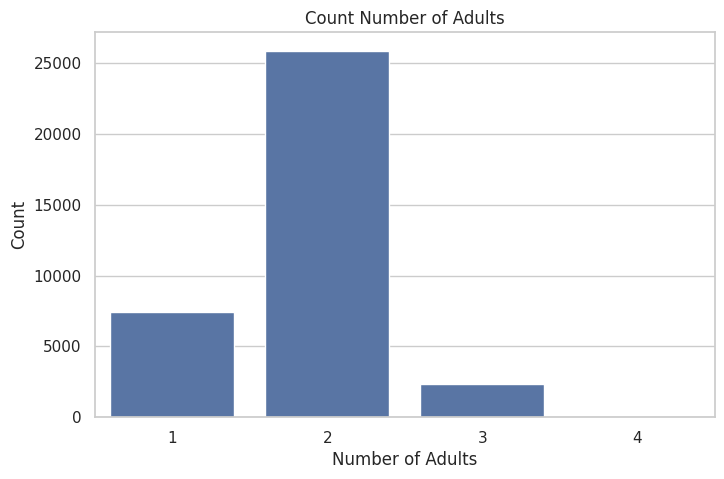

In [ ]:
#Distribution plot for Number of Adults
plt.figure(figsize = (8,5))
sns.countplot(x ="no_of_adults", data=df)
plt.title("Count Number of Adults")
plt.xlabel("Number of Adults")
plt.ylabel("Count")
plt.show()

###Observation:
- Most bookings are nade for 1-2 adulrs, making it the most common group size.
- Bookings with 1 adult are also significant but lower in comparison.
- Larger group bookings (3 or more adults) are relatively rare.

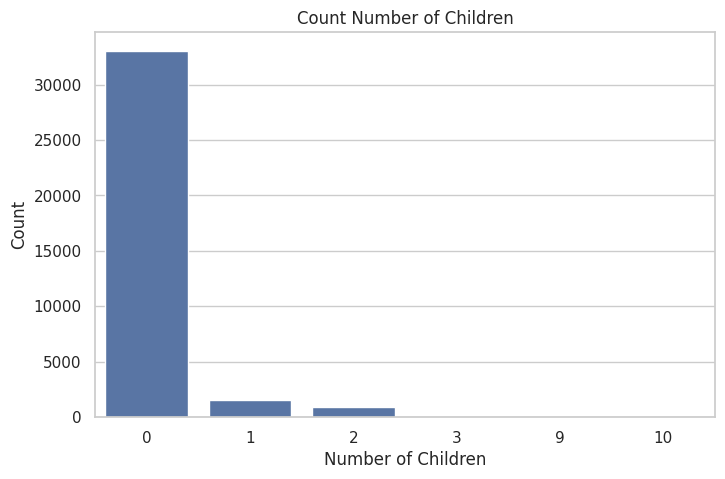

In [ ]:
#Distribution plot for Number of Children
plt.figure(figsize = (8,5))
sns.countplot(x ="no_of_children", data=df)
plt.title("Count Number of Children")
plt.xlabel("Number of Children")
plt.ylabel("Count")
plt.show()

###Observation:
- The majority of bookings have 0 children, indicating most guests are not traveling with kids.
- Bookings with 1 or 2 children are significantly fewer.
- A few extreme values are observed, which may indicate outliers or rare cases.

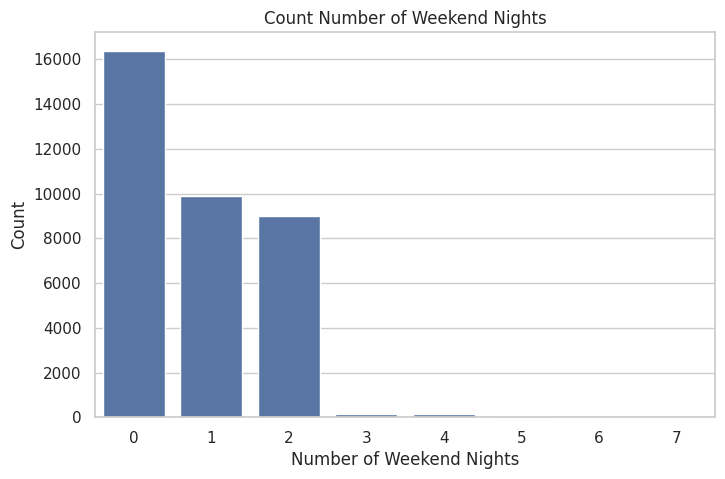

In [ ]:
#Distribution plot for Number of Weekend Nights
plt.figure(figsize = (8,5))
sns.countplot(x = 'no_of_weekend_nights', data=df)
plt.title("Count Number of Weekend Nights")
plt.xlabel("Number of Weekend Nights")
plt.ylabel("Count")
plt.show()

###Observation:
- Most bookings include 0-2 weekend nights, with 0 being the most frequent.
- The distribution is slightly right-skewed, indicating fewer bookings with longer weekend stays.
- Weekend stays beyond 2 nights are relatively rare.

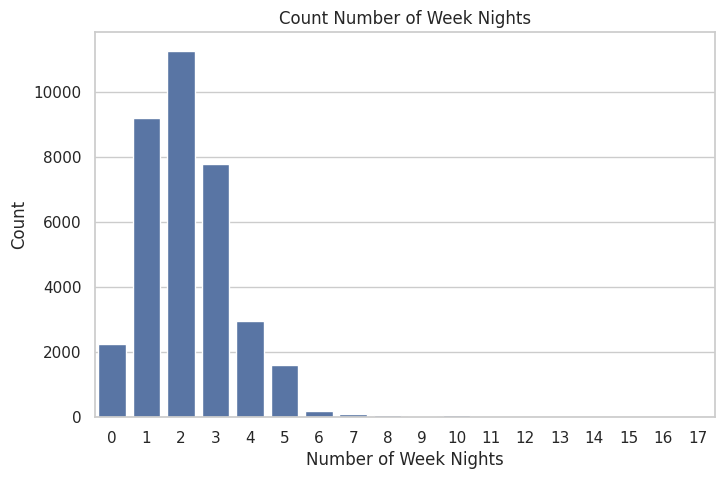

In [ ]:
#Distribution plot for Number of Week Nights
plt.figure(figsize = (8,5))
sns.countplot(x = 'no_of_week_nights', data=df)
plt.title("Count Number of Week Nights")
plt.xlabel("Number of Week Nights")
plt.ylabel("Count")
plt.show()

###Observation:
- Most bookings include 1-3 week nights, with 2 nights being the most common.
- The distribution is right-skewed, indicating fewer bookings with longer stays.
- Week night stays beyond 4-5 days are relatively rare.

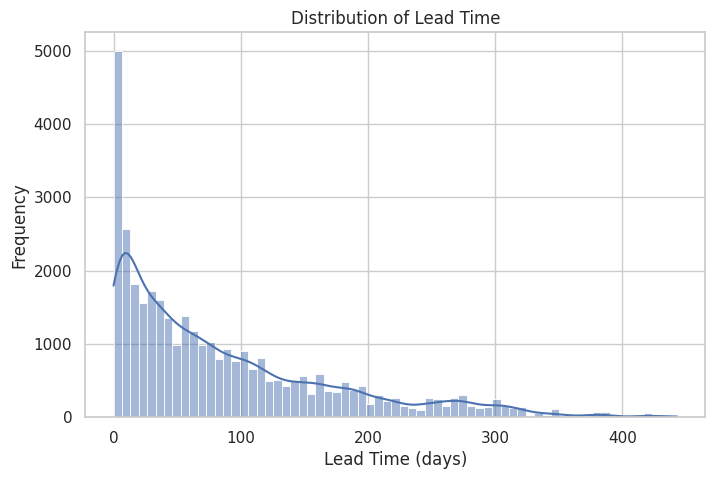

Skewness: 1.2842423468486988


In [ ]:
#Distribution plot for Lead Time
plt.figure(figsize=(8,5))
sns.histplot(df['lead_time'], kde = True)
plt.title("Distribution of Lead Time")
plt.xlabel("Lead Time (days)")
plt.ylabel("Frequency")
plt.show()

print("Skewness:", df['lead_time'].skew())

###Observation:
- Lead time is highly right-skewed, with most bookings made close to the arrival date.
- A gradual decline is observed as lead time increases, indicating fewer early bookings.
- Some extreme values are present, showing that a small number of customers book far in advance.

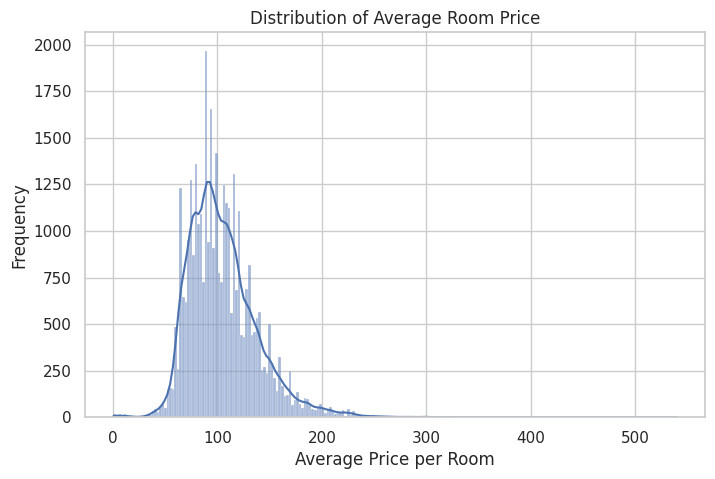

Skewness: 1.1600863299946313


In [ ]:
#Distribution plot for Average Price per Room
plt.figure(figsize=(8,5))
sns.histplot(df['avg_price_per_room'], kde = True)
plt.title("Distribution of Average Room Price")
plt.xlabel("Average Price per Room")
plt.ylabel("Frequency")
plt.show()

print("Skewness:", df['avg_price_per_room'].skew())

###Observation:
- The distribution of average room price is right-skewed, with most bookings concentrated around a moderate price range.
- Prices are primarily clustered between lower to mid-range values, indicating typical booking costs.
- A few higher price values are present, suggesting premium bookings or peak pricing periods.

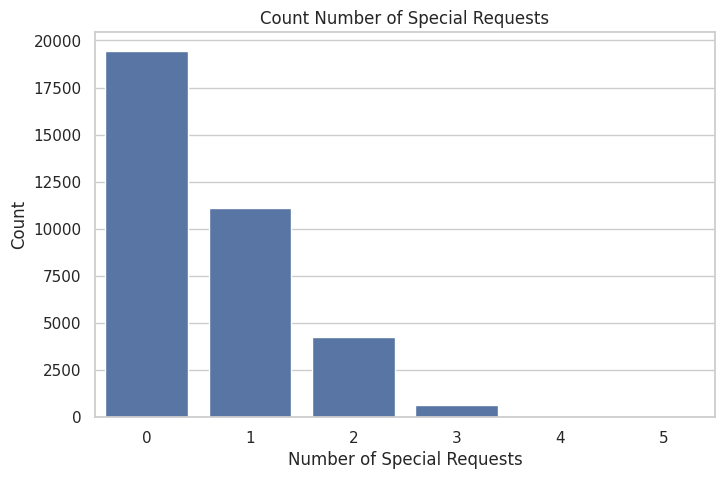

In [ ]:
#Distribution plot for Number of Special Requests
plt.figure(figsize = (8,5))
sns.countplot(x = 'no_of_special_requests', data=df)
plt.title("Count Number of Special Requests")
plt.xlabel("Number of Special Requests")
plt.ylabel("Count")
plt.show()

###Observation:
- Most customers make no special requests, making it the most common case.
- A significant number of bookings include 1-2 requests.
- Higher number of special requests are rare, indicating limited customization in most bookings.

###For Categorical Variables

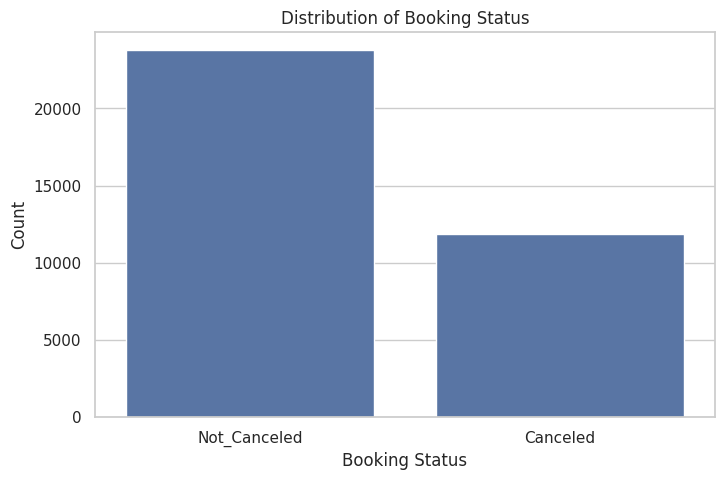

In [ ]:
#Distribution plot for Booking Status (Target Variable)
plt.figure(figsize=(8,5))
sns.countplot(x = 'booking_status', data=df)
plt.title("Distribution of Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Count")
plt.show()

###Observation:
- Non-canceled bookings are significantly higher than canceled bookings.
- However, cancellations still represent a substantial portion of the data.
- This indicates a moderate class imbalance in the target variable.

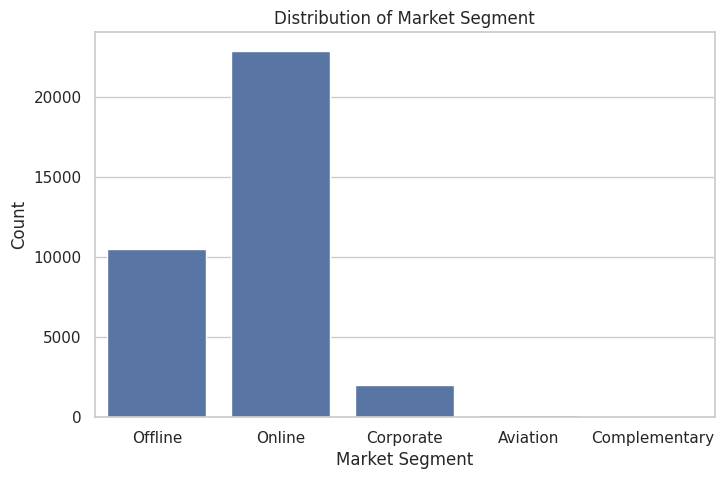

In [ ]:
#Distribution plot for Market Segment
plt.figure(figsize=(8,5))
sns.countplot(x = 'market_segment_type', data=df)
plt.title("Distribution of Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Count")
plt.show()

###Observation:
- Online bookings dominate the dataset, making it the primary source of reservations.
- Offline bookings are the second most common segment.
- Corporate bookings contribute a smaller portion, while aviation and complementary segments are minimal.

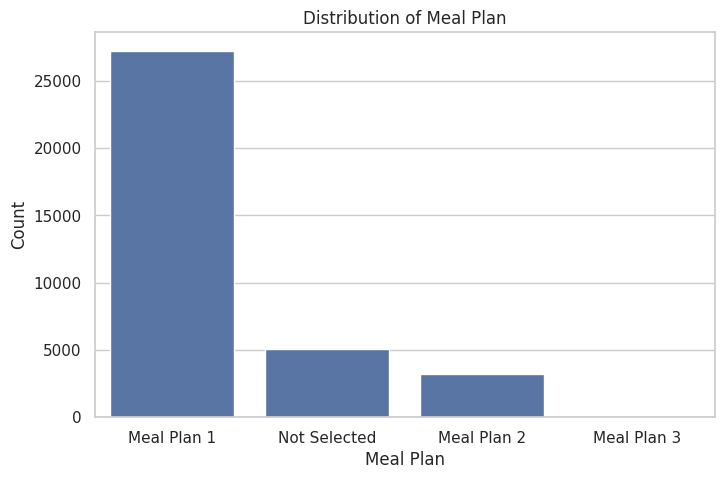

In [ ]:
#Distribution plot for Meal Plan
plt.figure(figsize=(8,5))
sns.countplot(x = 'type_of_meal_plan', data=df)
plt.title("Distribution of Meal Plan")
plt.xlabel("Meal Plan")
plt.ylabel("Count")
plt.show()

###Observation:
- Meal Plan 1 is the most preferred option by a large margin.
- A moderate number of customers do not select any meal plan.
- Meal Plan 2 has fewer bookings, while Meal Plan 3 is almost negligible.

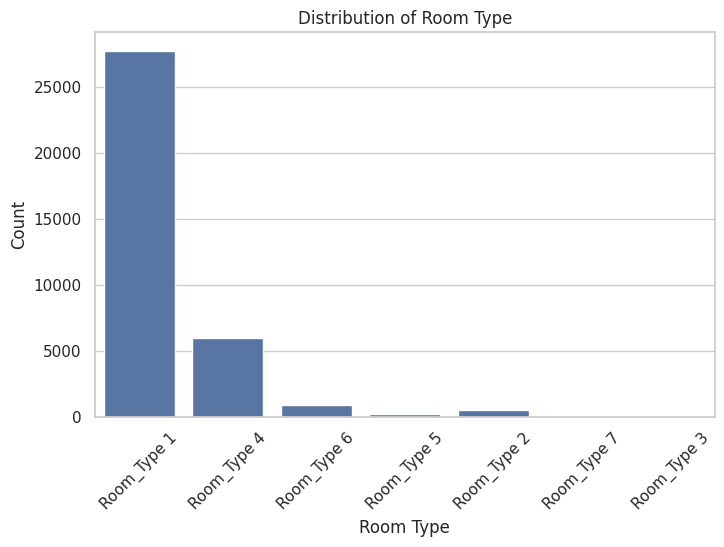

In [ ]:
#Distribution plot for Room Type
plt.figure(figsize=(8,5))
sns.countplot(x = 'room_type_reserved', data=df)
plt.xticks(rotation=45)
plt.title("Distribution of Room Type")
plt.xlabel("Room Type")
plt.ylabel("Count")
plt.show()

###Observation:
- Room Type 1 is overwhelmingly the most preferred option among customers.
- Room Type 4 is the second most booked, but significantly lower than Room Type 1.
- Other room types have very low booking frequencies, indicating limited demand.

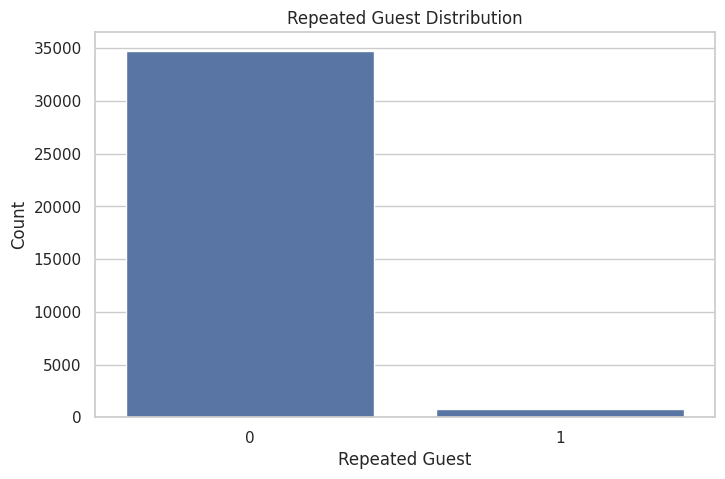

In [ ]:
#Distribution plot for Repeated Guest
plt.figure(figsize=(8,5))
sns.countplot(x = 'repeated_guest', data=df)
plt.title("Repeated Guest Distribution")
plt.xlabel("Repeated Guest")
plt.ylabel("Count")
plt.show()

###Observation:
- The vast majority of customers are not repeated guests.
- Only a very small proportion of bookings come from returning customers.
- This indicates low customer retention or that most bookings are from new customers.

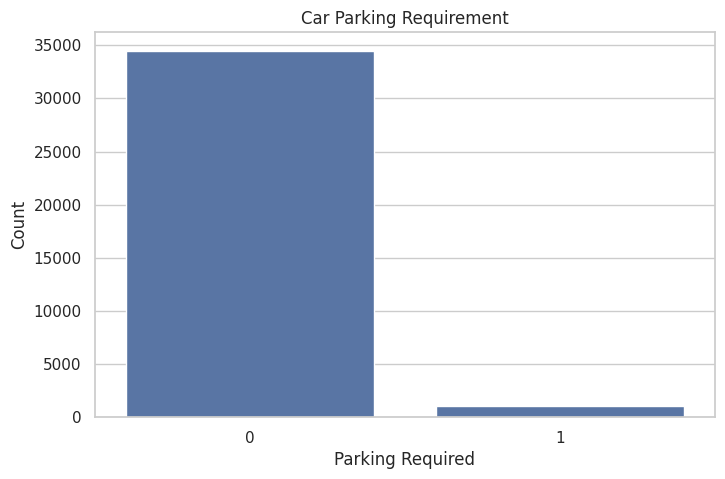

In [ ]:
#Distribution plot for Required Car Parking
plt.figure(figsize=(8,5))
sns.countplot(x = 'required_car_parking_space', data=df)
plt.title("Car Parking Requirement")
plt.xlabel("Parking Required")
plt.ylabel("Count")
plt.show()

###Observation:
- Most customers do not require car parking.
- Only a small proportion of bookings include a parking requirement.
- This suggests that parking demand is relatively low among guests.

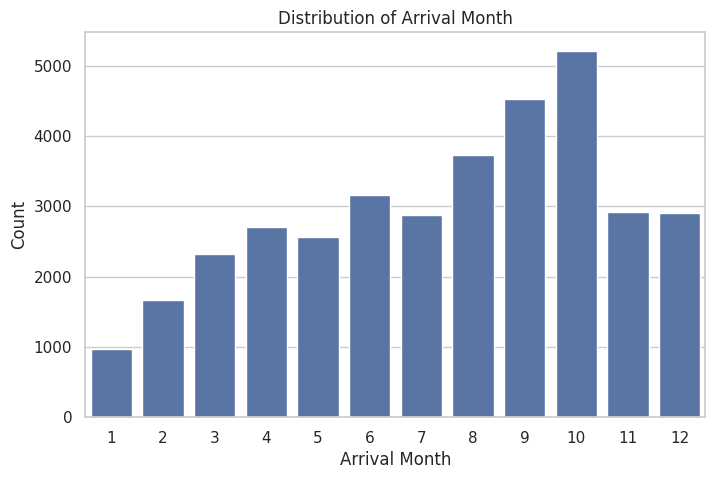

In [ ]:
#Distribution plot for Arrival Month
plt.figure(figsize=(8,5))
sns.countplot(x = 'arrival_month', data=df)
plt.title("Distribution of Arrival Month")
plt.xlabel("Arrival Month")
plt.ylabel("Count")
plt.show()

###Observation:
- Bookings increase gradually from the beginning of the year and peak around months 9 and 10.
- Higher booking volumes in later months indicate seasonal demand trends.
- Early months have relatively lower bookings compared to mid and late-year periods.

##Bivariate Analysis
###Numerical Variables vs Target Variable (booking_status)

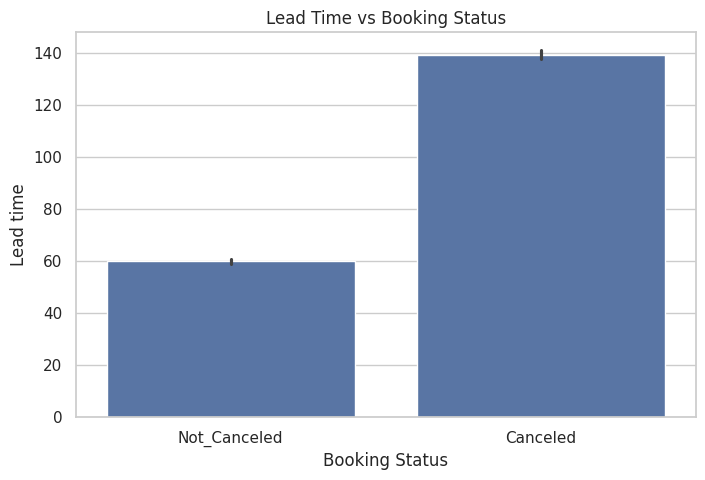

In [ ]:
#Lead Time vs Booking Status
plt.figure(figsize=(8,5))
sns.barplot(x='booking_status', y='lead_time', data=df)
plt.title("Lead Time vs Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Lead time")
plt.show()

###Observation:
Canceled bookings have a significantly higher average lead time compared to non-canceled bookings. This indicates that reservations made well im advance are more likely to be canceled, while bookings made closer to the arrival date tend to be more reliable.

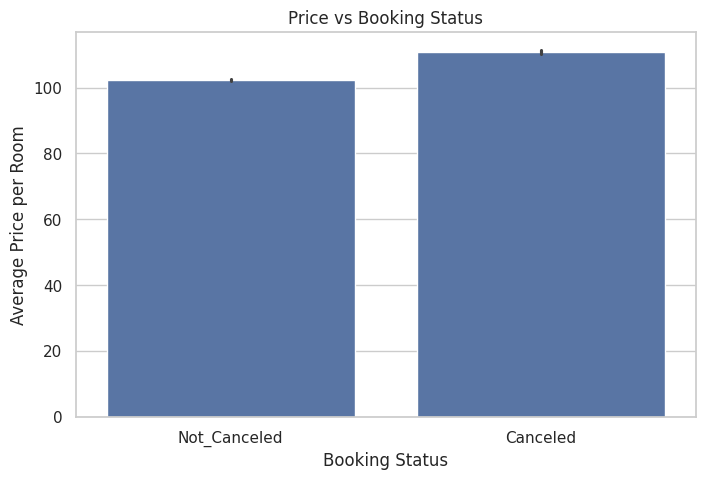

In [ ]:
#Average Price vs Booking Status
plt.figure(figsize=(8,5))
sns.barplot(x='booking_status', y='avg_price_per_room', data=df)
plt.title("Price vs Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Average Price per Room")
plt.show()

###Observation:
The median room price is slightly higher for canceled bookings compared to non-canceled bookings. However, the difference is not very large, suggesting that price alone does not have a strong influence on whether a booking gets canceled.

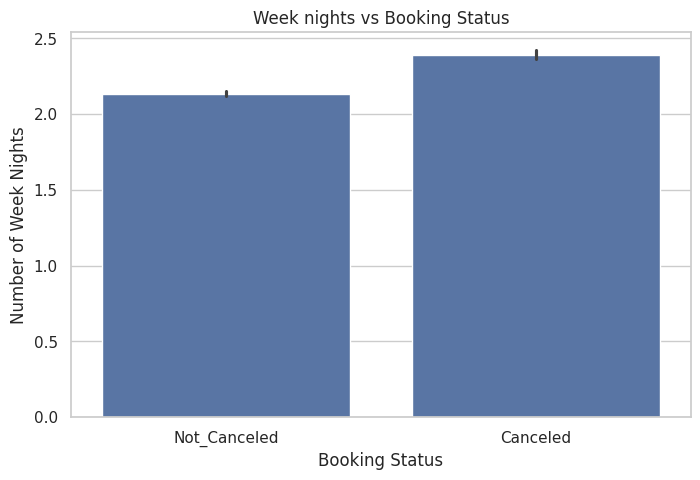

In [ ]:
#Number of Week Nights vs Booking Status
plt.figure(figsize=(8,5))
sns.barplot(x='booking_status', y='no_of_week_nights', data=df)
plt.title("Week nights vs Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Number of Week Nights")
plt.show()

###Observation:
The average number of week nights is slightly higher for canceled bookings compared to non-canceled bookings. However, the difference is minimal, indicating that the number of week nights does not have a strong impact on booking cancellations.

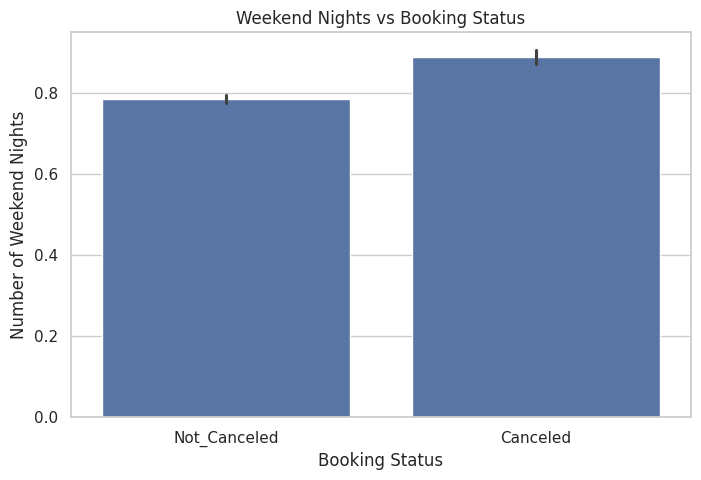

In [ ]:
#Number of Weekend Nights vs Booking Status
plt.figure(figsize=(8,5))
sns.barplot(x='booking_status', y='no_of_weekend_nights', data=df)
plt.title("Weekend Nights vs Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Number of Weekend Nights")
plt.show()

###Observation:
Canceled bookings have a slightly higher average number of weekend nights compared to non-canceled bookings. However, the difference is very small, indicating that weekend stay duration does not significantly influence booking cancellations.

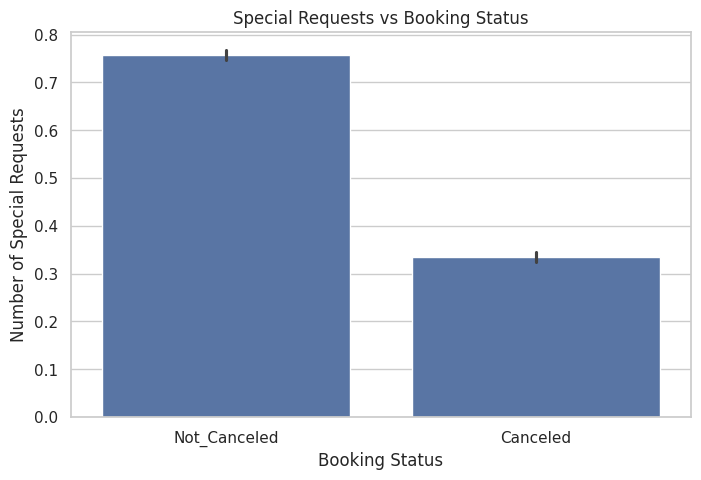

In [ ]:
#Number of Special Requests vs Booking Status
plt.figure(figsize=(8,5))
sns.barplot(x='booking_status', y='no_of_special_requests', data=df)
plt.title("Special Requests vs Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Number of Special Requests")
plt.show()

###Observation:
Non-canceled bookings have a higher average number of special requests compared to canceled bookings. This suggests that customers who make more special requests are more engaged and less likely to cancel their bookings.

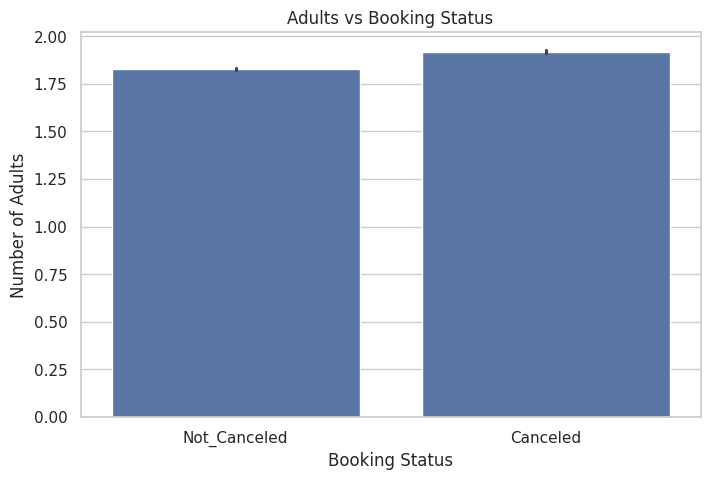

In [ ]:
#Number of Adults vs Booking Status
plt.figure(figsize=(8,5))
sns.barplot(x='booking_status', y='no_of_adults', data=df)
plt.title("Adults vs Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Number of Adults")
plt.show()

###Observation:
The average number of adults is nearly the same for both canceled and non-canceled bookings, with only a slight increase for canceled bookings. This indicates that the number of adults does not have a significant impact on booking cancellations.

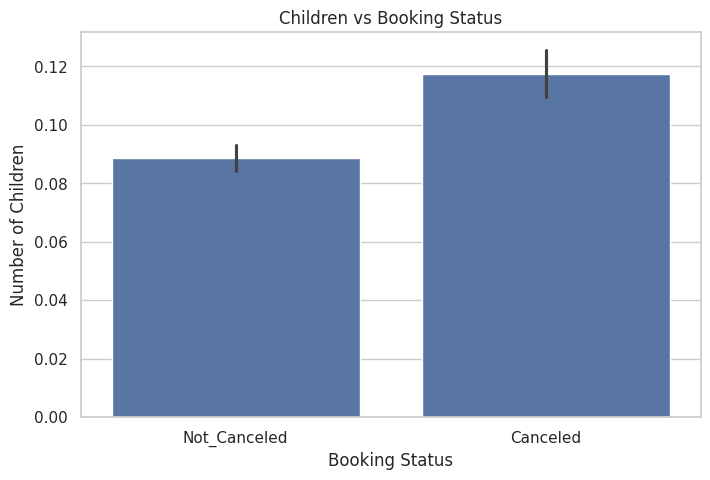

In [ ]:
#Number of Children vs Booking Status
plt.figure(figsize=(8,5))
sns.barplot(x='booking_status', y='no_of_children', data=df)
plt.title("Children vs Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Number of Children")
plt.show()

###Observation:
The average number of children is slightly higher for canceled bookings compared to non-canceled bookings. However, the overall values are very low in both cases, indicating that the presence of children does not significantly influence booking cancellations.

###Categorical Variables vs Target Variable (booking_status)

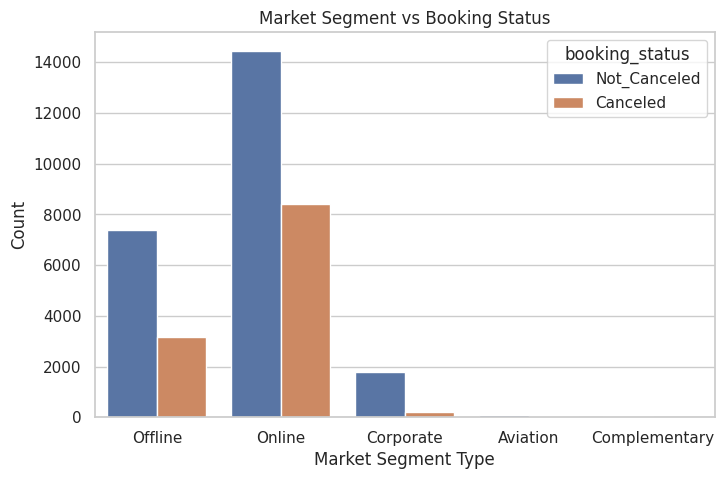

In [ ]:
#Market Segment vs Booking Status
plt.figure(figsize=(8,5))
sns.countplot(x='market_segment_type', hue='booking_status', data=df)
plt.title("Market Segment vs Booking Status")
plt.xlabel("Market Segment Type")
plt.ylabel("Count")
plt.show()

###Observation:
- The online segment has the highest number of both canceled and non-canceled bookings.
- Offline bookings also show a noticeable number of cancellations, though lower than online.
- Corporate segment has relatively fewer cancellations compared to total bookings.
- Aviation and complementary segments have very low booking volumes abd minimal cancellations.

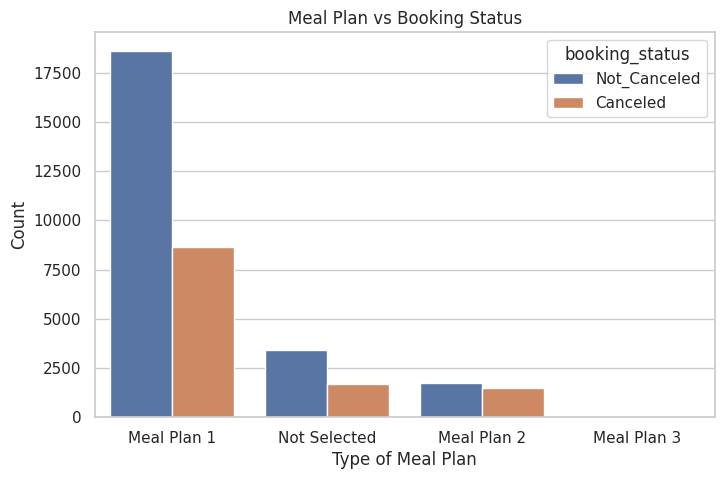

In [ ]:
#Meal Plan vs Booking Status
plt.figure(figsize=(8,5))
sns.countplot(x='type_of_meal_plan', hue='booking_status', data=df)
plt.title("Meal Plan vs Booking Status")
plt.xlabel("Type of Meal Plan")
plt.ylabel("Count")
plt.show()

###Observation:
- Meal Plan 1 has the higest number of both canceled and non-canceled bookings.
- The proportion of cancellations is noticeable across all meal plans.
- Meal Plan 2 and "Not Selected" show relatively similar cancellation patterns.
- Meal Plan type does not show a strong distinction in cancellation behavior.

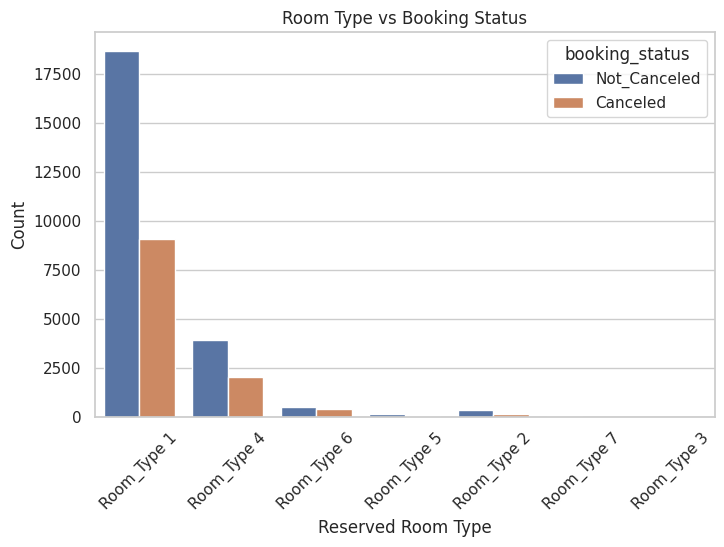

In [ ]:
#Room Type vs Booking Status
plt.figure(figsize=(8,5))
sns.countplot(x='room_type_reserved', hue='booking_status', data=df)
plt.xticks(rotation=45)
plt.title("Room Type vs Booking Status")
plt.xlabel("Reserved Room Type")
plt.ylabel("Count")
plt.show()

###Observation:
- Room Type 1 has the higest number of both canceled and non-canceled bookings.
- Room Type 4 also shows a noticeable number of cancellations but is significantly lower than Room Type 1.
- Other room types have very low booking volumes, making it difficult to draw strong conclusions.
- Overall, room type does not show a strong distinction in cancellation behavior.

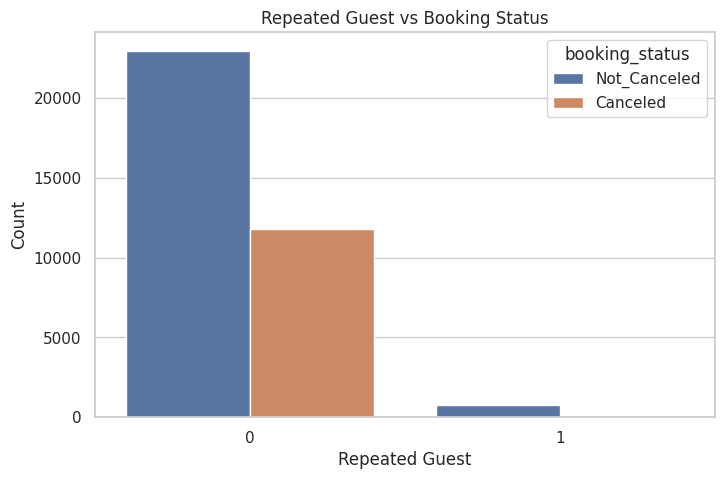

In [ ]:
#Repeated Guest vs Booking Status
plt.figure(figsize=(8,5))
sns.countplot(x='repeated_guest', hue='booking_status', data=df)
plt.title("Repeated Guest vs Booking Status")
plt.xlabel("Repeated Guest")
plt.ylabel("Count")
plt.show()

###Observation:
- Most bookings are from non-repeated guests, and they account for the majority of cancellations.
- Repeated guests have very few cancellations compared to non-repeated guests.
- This indicates that repeated guests are more reliable and less likely to cancel bookings.

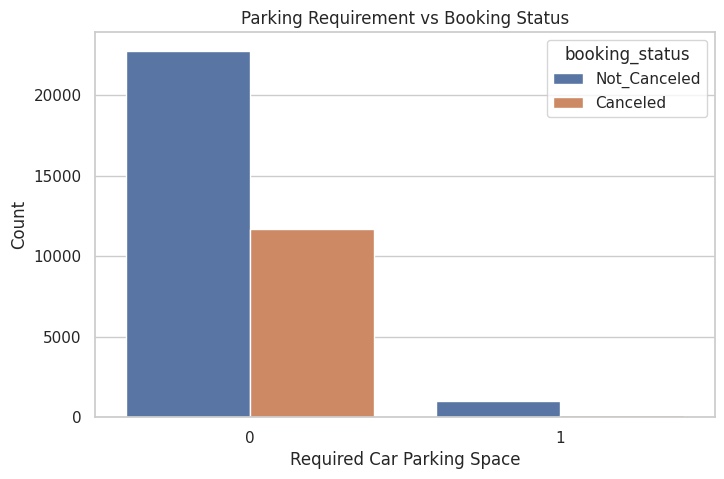

In [ ]:
#Car Parking Requirement vs Booking Status
plt.figure(figsize=(8,5))
sns.countplot(x='required_car_parking_space', hue='booking_status', data=df)
plt.title("Parking Requirement vs Booking Status")
plt.xlabel("Required Car Parking Space")
plt.ylabel("Count")
plt.show()

###Observation:
- Most bookings are from customers who do not require parking, and they account for the majority of cancellations.
- Customers who require parking show very few cancellations.
- This suggests that customers requesting parking are more committed and less likely to cancel.

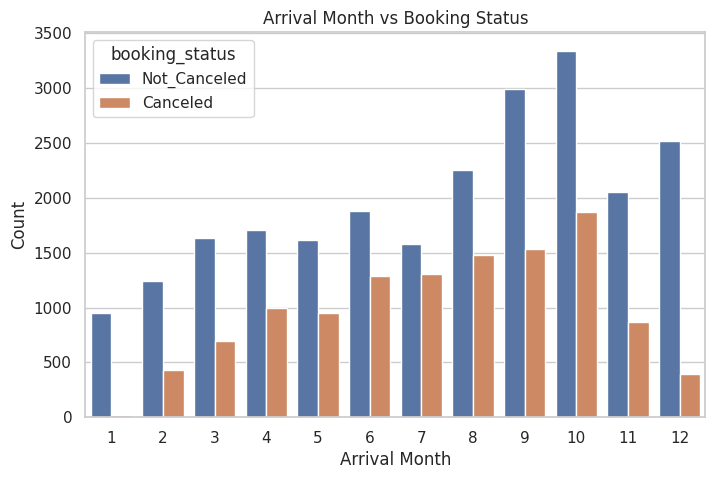

In [ ]:
#Arrival Month vs Booking Status
plt.figure(figsize=(8,5))
sns.countplot(x='arrival_month', hue='booking_status', data=df)
plt.title("Arrival Month vs Booking Status")
plt.xlabel("Arrival Month")
plt.ylabel("Count")
plt.show()

###Observation:
- Bookings increase in later months, with peaks around months 9 and 10.
- Cancellations also rise during these high-demand months.
- Some mid-year months (around 6-8) show relatively higher cancellation proportions.
- This indicates that both bookings and cancellations are influenced by seasonal trends.

##Appropriate Visualizations to identify Patterns and Insights

- Histrograms with KDE plots were used for numerical variables to understand distribution, skewness, and presence of outliers (e.g., lead time and room price).
- Count plots were used for categorical variables to identify dominant categories such as market segment, meal plan, and room type.
- Box plots were used to analyze relationships between numerical variables and booking status, helping identify differences in distributions (e.g., lead time vs cancellation).
- Grouped count plots (with hue) were used to compare categorical variables with booking status, revealing patterns in customer behavior (e.g., repeated guests and market segments).
- These visualizations helped uncover key patterns such as:
    * Higher lead time associated with cancellations.
    * Lower cancellation rates among repeated guests.
    * Seasonal trends in bookings and cancellations.
    * Dominance of online booking channels.

##Answers to the EDA Questions
###1. What are the busiest months in the hotel?

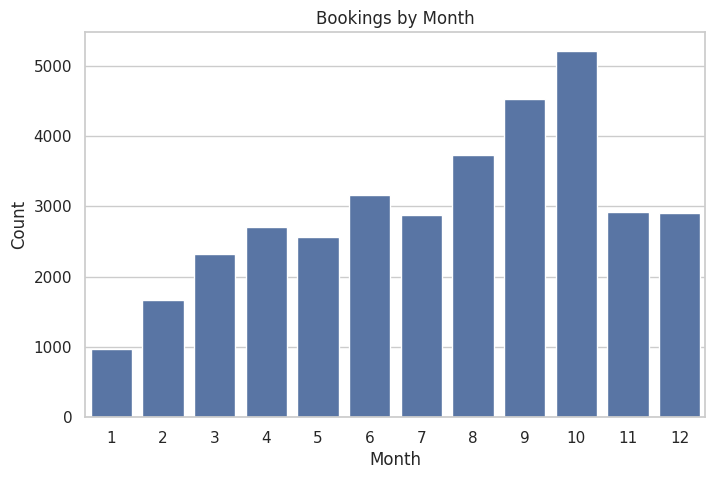

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='arrival_month', data=df)
plt.title("Bookings by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

###Answer:
The busiest months in the hotel are September and October, as they show the highest number of bookings. There is a gradual increase in bookings from the beginning of the year, which peaks during these months, indicating a strong seasonal demand pattern in the later part of the year.

###2. Which market segment do most of the guests come from?

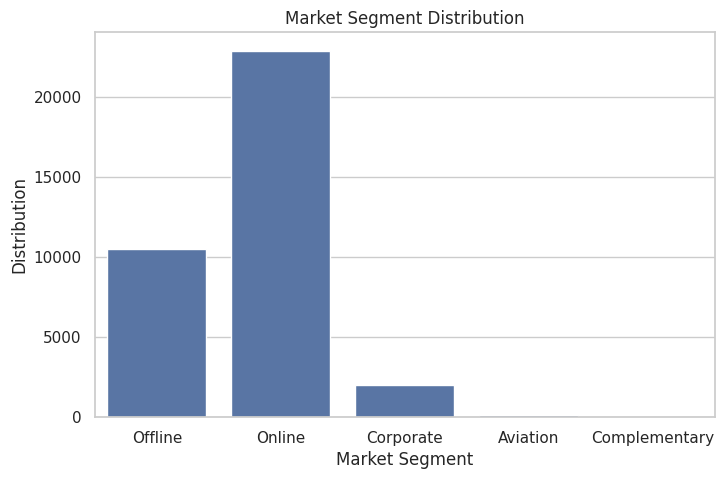

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='market_segment_type', data=df)
plt.title("Market Segment Distribution")
plt.xlabel("Market Segment")
plt.ylabel("Distribution")
plt.show()

###Answer:
The majority of guests come from the online market segment, which clearly dominates the booking distribution. Offline bookings form the second largest group, while corporate, aviation, and complementary segments contribute relatively fewer bookings. This shows that online platforms are primary source of hotel reservations.

###3. Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?

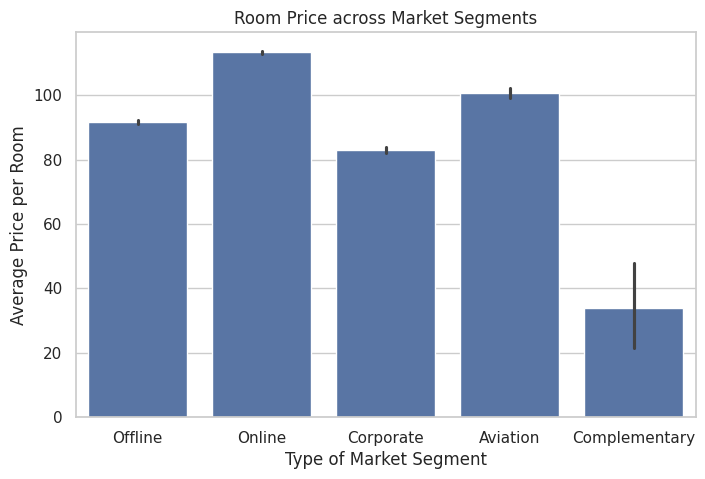

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='market_segment_type', y='avg_price_per_room', data=df)
plt.title("Room Price across Market Segments")
plt.xlabel("Type of Market Segment")
plt.ylabel("Average Price per Room")
plt.show()

###Answer:
Room prices differ across market segments, with the online segment having the highest average room price, followed by the aviation and offline segments. The corporate segment shows relatively lower and more stable pricing, while the complementary segment has the lowest prices, indicating discounted or free bookings. Overall, this variation reflects different pricing strategies based on customer type and booking channel.

###4. What percentage of bookings are canceled?

In [ ]:
print(df['booking_status'].value_counts(normalize = True) * 100)

booking_status
Not_Canceled    66.750948
Canceled        33.249052
Name: proportion, dtype: float64


###Answer:
Approximately 33% of the bookings are canceled, indicating that a significant portion of reservations do not materialize into actual stays. This highlights the uncertainty in booking behavior and its potential impact on hotel revenue and resource planning.

###5. Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel?

In [ ]:
print(pd.crosstab(
    df['repeated_guest'],
    df['booking_status'],
    normalize='index') * 100)

booking_status   Canceled  Not_Canceled
repeated_guest                         
0               33.970453     66.029547
1                1.992528     98.007472


###Answer:
Only about 2% of repeated guests cancel their bookings, while approximately 98% o them do not cancel. In contrast, non-repeated guests have a much higher cancellation rate of around 34%. This clearly indicates that repeated guests are significantly more reliable and are far less likely to cancel their bookings compared to new customers.

###6. Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?

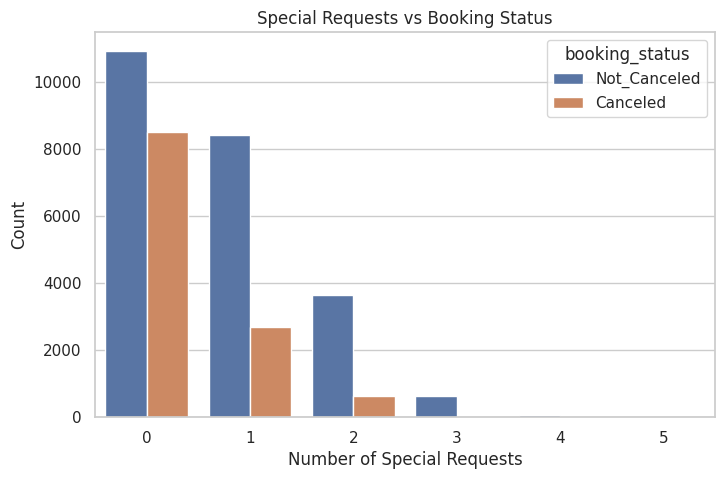

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='no_of_special_requests', hue='booking_status', data=df)
plt.title("Special Requests vs Booking Status")
plt.xlabel("Number of Special Requests")
plt.ylabel("Count")
plt.show()

###Answer:
Yes, special requests appear to have a noticeable impact on booking cancellations. Customers with no special requests show a relatively higher number of cancellations, while those with one or more requests tend to have a higher proportion of non-canceled bookings. As the number of special requests increases, cancellations decrease significantly, indicating that customers who make special requests are more engaged and committed to their bookings, and are therefore less likely to cancel.

##Key Observations
###Individual Variables:
- Most bookings involve 1-2 adults with no children, indicating small group stays.
- The duration of stay is generally short, with most bookings having 1-3 week nights and 0-2 weekend nights.
- The majority of bookings come from the online market segment, followed by offline.
- Meal Plan 1 and Room Type 1 are the most preferred options among customers.
- Most customers are non-repeated guests, indicating low customer retention.
- The number of special requests is generally low, with most customers making 0-1 requests.
- Bookings show a seasonal trend, increasing through the year and peaking in later months (September-October).

###Relationship Between Variables
- Lead time is a strong factor, with higher lead times associated with more cancellations.
- Repeated guests have significantly lower cancellation rates, indicating higher reliability.
- Customers who request parking or make special requests are less likely to cancel, showing higher commitment.
- Market segment influences cancellation behavior, with online bookings contributing the most to cancellations due to higher volume.
- Price varies across segments, but it does not strongly differentiate between canceled and non-canceled bookings.
- Variables such as number of adults, children, and length of stay show minimal impact on cancellations.
- Seasonality affects both bookings and cancellations, with higher activity observed in peak months.

#Data Preprocessing
##Missing Value Treatment



In [ ]:
print(df.isnull().sum())

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64


###Observation:
No missing values are present in the dataset. Therefore, no imputation or removal is required.

##Outlier Detection

In [ ]:
#Identifying Numerical Columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Columns:")
print(numerical_cols)

Numerical Columns:
Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests'],
      dtype='object')


###Visual Inspection of Outliers using Boxplot

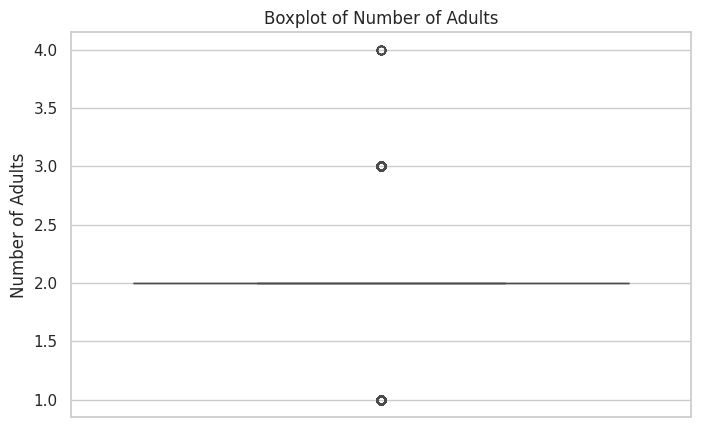

In [ ]:
#Check for outliers in the 'no_of_adults' column
plt.figure(figsize=(8,5))
sns.boxplot(y=df['no_of_adults'])
plt.title("Boxplot of Number of Adults")
plt.ylabel("Number of Adults")
plt.show()

###Observation:
The number of adults is highly concentrated at 2, with almost all bookings falling in this category. This results in a collapsed boxplot (a single line), indicating very low variability. A few values (1,3, and 4 adults) appear as outliers, but overall, the number of adults does not vary significantly aross bookings.

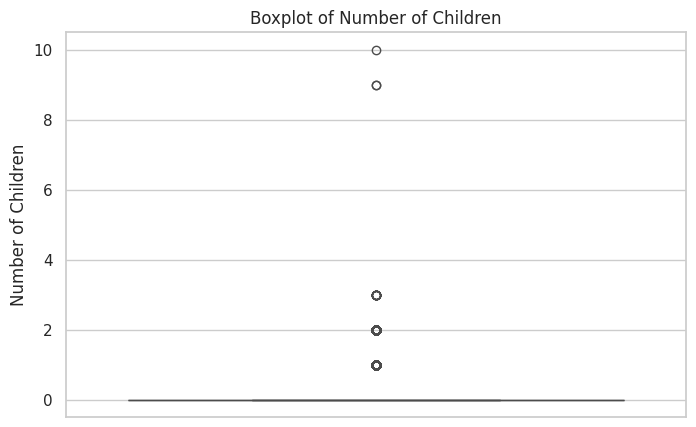

In [ ]:
#Check for outliers in the 'no_of_children' column
plt.figure(figsize=(8,5))
sns.boxplot(y=df['no_of_children'])
plt.title("Boxplot of Number of Children")
plt.ylabel("Number of Children")
plt.show()

###Observation:
The number of children is highly concentrated at 0, indicating that most bookings do not include children. A few higher values (such as 1,2,3, and extreme cases like 9 and 10) appear as outliers, showing that only a small proportion of bookings involve families with children. Overall, the distribution is highly skewed with very low variability.

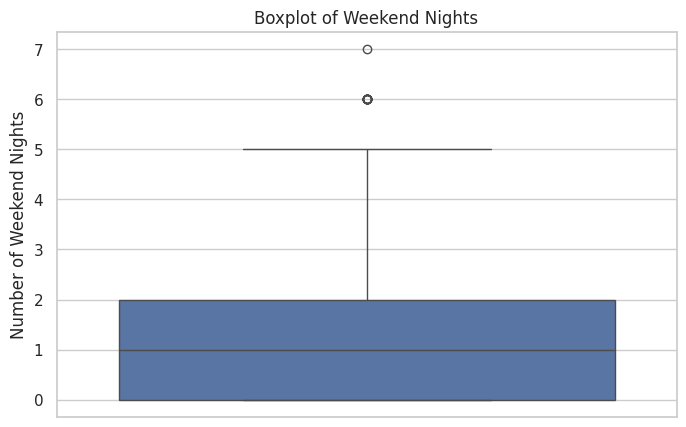

In [ ]:
#Check for outliers in the 'no_of_weekend_nights' column
plt.figure(figsize=(8,5))
sns.boxplot(y=df['no_of_weekend_nights'])
plt.title("Boxplot of Weekend Nights")
plt.ylabel("Number of Weekend Nights")
plt.show()

###Observation:
The number of weekend nights is mostly concentrated between 0 and 2, with a median around 1, indicating that most guests stay for short weekend durations. A few higher values (6 and 7 nights) appear as outliers, representing rare cases of longer weekend stays. Overall, the distribution shows moderate variability with a slight right skew.

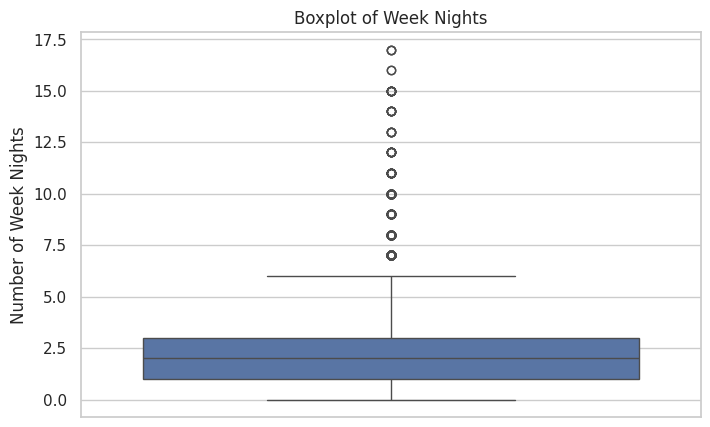

In [ ]:
#Check for outliers in the 'no_of_week_nights' column
plt.figure(figsize=(8,5))
sns.boxplot(y=df['no_of_week_nights'])
plt.title("Boxplot of Week Nights")
plt.ylabel("Number of Week Nights")
plt.show()

###Observation:
The number of week nights is mostly concentrated between 1 and 3 nights, with a median around 2, indicating that most guests have short weekday stays. Several higher values (above 7 nights) appear as outliers, representing longer stays that are relatively uncommon. The distribution is right-skewed, showing that while most bookings are short, a few extend to longer durations.

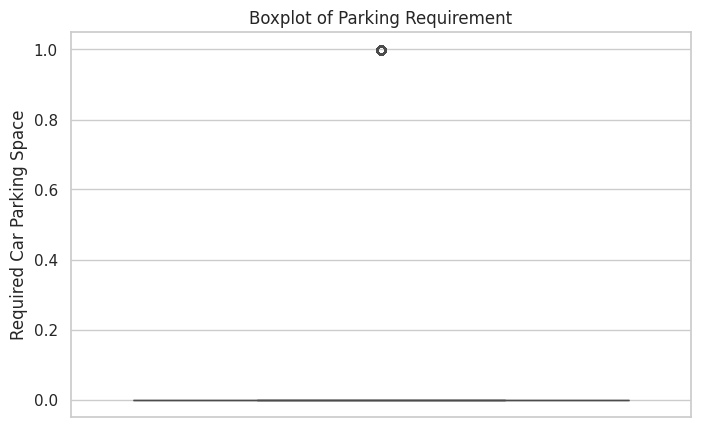

In [ ]:
#Check for outliers in the 'required_car_parking_space' column
plt.figure(figsize=(8,5))
sns.boxplot(y=df['required_car_parking_space'])
plt.title("Boxplot of Parking Requirement")
plt.ylabel("Required Car Parking Space")
plt.show()

###Observation:
The parking requirement variable is binary (0 or 1) is highly concentrated at 0, indicating that most customers do not require parking. The value 1 appears as a separate point, but it is not an outlier; rather, it represents the minority class. Outlier detection is not meaningful for this variable.

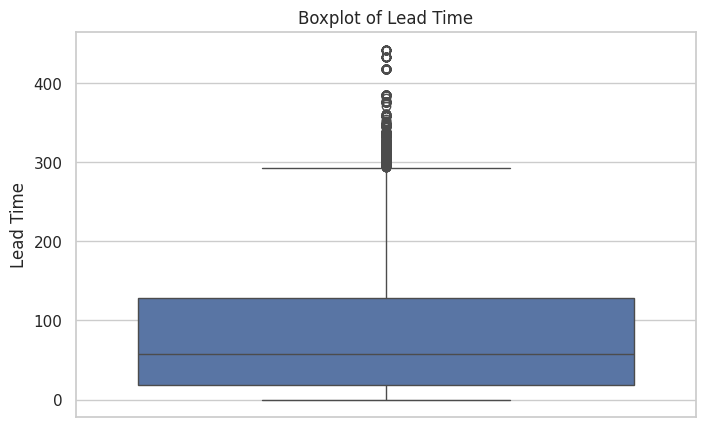

In [ ]:
#Check for outliers in the 'lead_time' column
plt.figure(figsize=(8,5))
sns.boxplot(y=df['lead_time'])
plt.title("Boxplot of Lead Time")
plt.ylabel("Lead Time")
plt.show()

###Observation:
The lead time shows a wide spread with a median around 50-60 days, indicating that most bookings are made moderately in advance. However, there are numerous high value outliers extending beyond 300 days, reflecting bookings made far in advance. The distribution is strongly right-skewed, suggesting that while most customers book within a shorter time frame, a smaller proportion plan much earlier.

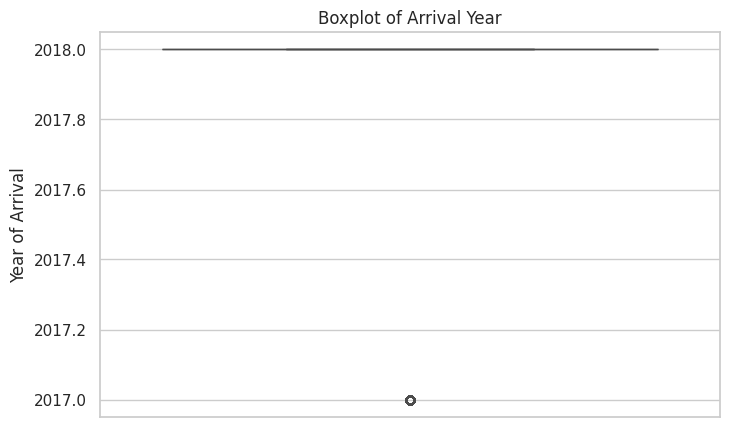

In [ ]:
#Check for outliers in the 'arrival_year' column
plt.figure(figsize=(8,5))
sns.boxplot(y=df['arrival_year'])
plt.title("Boxplot of Arrival Year")
plt.ylabel("Year of Arrival")
plt.show()

###Observation:
The arrival year variable contains only two values (2017 and 2018), with most bookings concentrated in 2018. The value 2017 appears as a separate point, but it is not an outlier; rather, it represents a smaller portion of the data. Outlier detection is not meaningful for this variable due to its discrete and limited range.

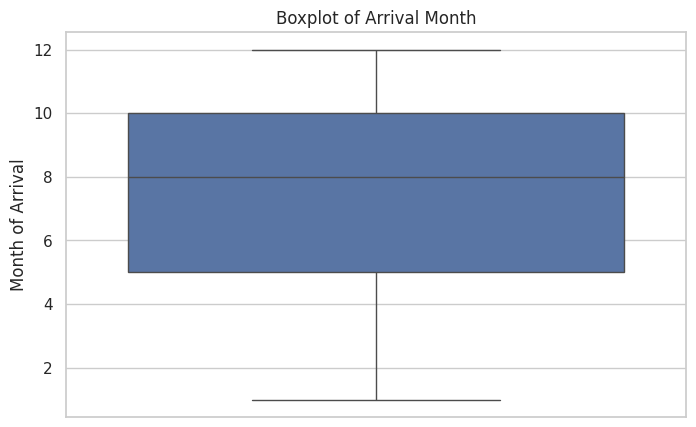

In [ ]:
#Check for outliers in the 'arrival_month' column
plt.figure(figsize=(8,5))
sns.boxplot(y=df['arrival_month'])
plt.title("Boxplot of Arrival Month")
plt.ylabel("Month of Arrival")
plt.show()

###Observation:
The arrival month is evenly distributed across the year, with values ranging from 1 to 12. The median lies around mid-year, indicating a balanced spread of bookings across different months. No outliers are observed, as this is a cyclical categorical variable represented numerically.

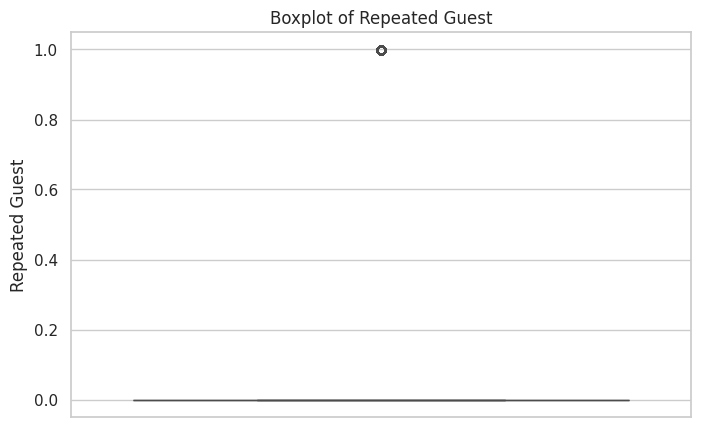

In [ ]:
#Check for outliers in the 'repeated_guest' column
plt.figure(figsize=(8,5))
sns.boxplot(y=df['repeated_guest'])
plt.title("Boxplot of Repeated Guest")
plt.ylabel("Repeated Guest")
plt.show()

###Observation:
The repeated_guest variable is binary (0 or 1) and is highly concentrated at 0, indicating that most customers are not repeated guests. The value 1 appears as a separate point, but it is not an outlier; it simply represents the minority class. Outlier detection is not meaningful for this variable.

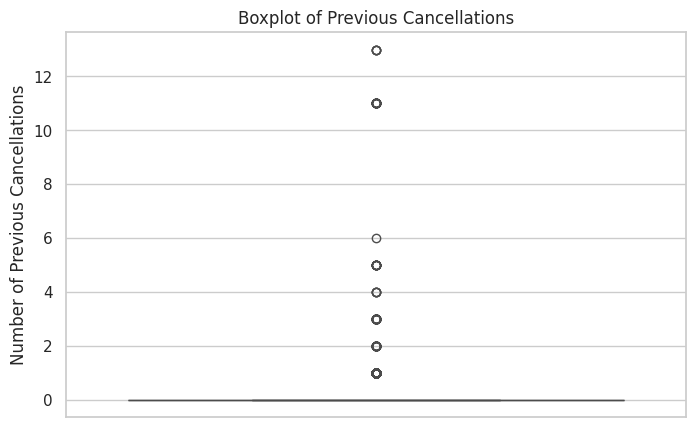

In [ ]:
#Check for outliers in the 'no_of_previous_cancellations' column
plt.figure(figsize=(8,5))
sns.boxplot(y=df['no_of_previous_cancellations'])
plt.title("Boxplot of Previous Cancellations")
plt.ylabel("Number of Previous Cancellations")
plt.show()

###Observation:
The number of previous cancellations is highly concentrated at 0, indicating that most customers have no prior cancellations. A few higher values (up to around 13) appear as outliers, representing customers with a history of multiple cancellations. The distribution is strongly right-skewed with low overall variability for the majority of the data.

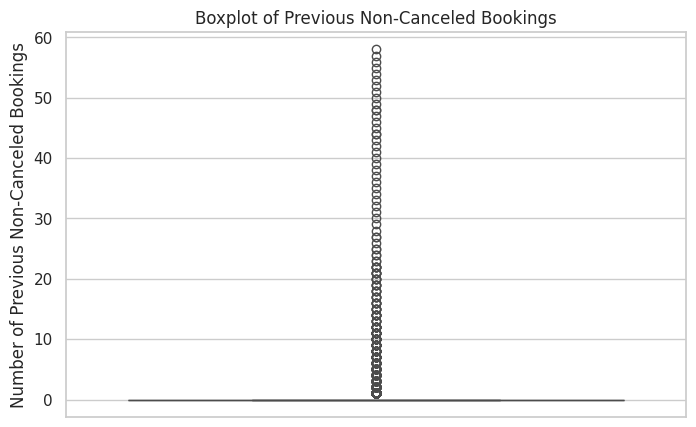

In [ ]:
#Check for outliers in the 'no_of_previous_bookings_not_canceled' column
plt.figure(figsize=(8,5))
sns.boxplot(y=df['no_of_previous_bookings_not_canceled'])
plt.title("Boxplot of Previous Non-Canceled Bookings")
plt.ylabel("Number of Previous Non-Canceled Bookings")
plt.show()

###Observation:
The number of previous non-canceled bookings is highly concentrated at 0, indicating that most customers have no prior booking history. A wide range of higher values (up to around 60) appear as outliers, representing a small group of frequent or loyal customers. The distribution is strongly right-skewed, with most data clustered at lower values.

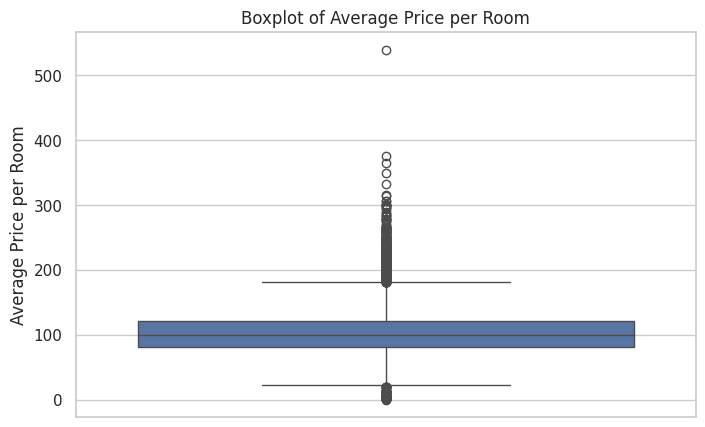

In [ ]:
#Check for outliers in the 'avg_price_per_room' column
plt.figure(figsize=(8,5))
sns.boxplot(y=df['avg_price_per_room'])
plt.title("Boxplot of Average Price per Room")
plt.ylabel("Average Price per Room")
plt.show()

###Observation:
The average price per room is mostly concentrated between 80 and 120, with a median around 100, indicating typical pricing for most bookings. However, there are several high-value outliers (above 200 and up to 500+) as well as a few very low values, showing significant variability in pricing. The distribution is right-skewed, suggesting that while most rooms are moderately priced, a small number of bookings are either premium-priced or heavily discounted.

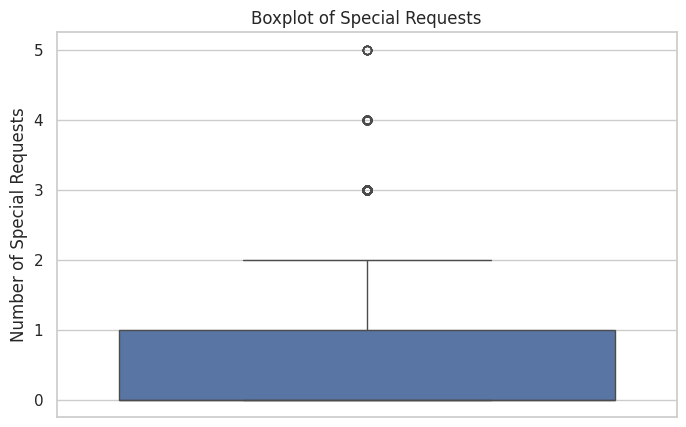

In [ ]:
#Check for outliers in the 'no_of_special_requests' column
plt.figure(figsize=(8,5))
sns.boxplot(y=df['no_of_special_requests'])
plt.title("Boxplot of Special Requests")
plt.ylabel("Number of Special Requests")
plt.show()

###Observation:
The number of special requests is mostly concentrated between 0 and 1, indicating that most customers make few or no special requests. A few higher values (3 to 5) appear as outliers, representing customers with multiple requests. The distribution is right-skewed, with low variability for the majority of bookings.

##Detecting Outliers using IQR Method

In [ ]:
#Continuous numerical variables
continuous_vars = ['lead_time', 'avg_price_per_room',
                   'no_of_weekend_nights', 'no_of_week_nights',
                   'no_of_special_requests']
for col in continuous_vars:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  print(f"{col}: {len(outliers)} outliers detected")

lead_time: 1182 outliers detected
avg_price_per_room: 1090 outliers detected
no_of_weekend_nights: 21 outliers detected
no_of_week_nights: 319 outliers detected
no_of_special_requests: 721 outliers detected


###Observation:
A large number of outliers are observed in **lead_time** and **avg_price_per_room**, indicating high variability in booking behavior and pricing. Moderate outliers are present in **no_of_week_nights** and **no_of_special_requests**, while **no_of_weekend_nights** has relatively fewer outliers. Overall, the presence of yhese outliers suggests a right-skewed distribution in several variables, reflecting real-world variations rather than data errors.

##Treating Outliers

In [ ]:
cols_to_treat = ['lead_time', 'avg_price_per_room',
                 'no_of_week_nights', 'no_of_special_requests']
for col in cols_to_treat:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 - 1.5 * IQR

  df[col] = df[col].clip(lower,upper)

#Rechecking Outliers
  outliers = df[(df[col] < lower) | (df[col] > upper)]
  print(f"{col}: {len(outliers)} outliers remaining")

lead_time: 0 outliers remaining
avg_price_per_room: 0 outliers remaining
no_of_week_nights: 0 outliers remaining
no_of_special_requests: 0 outliers remaining


###Observation:
After applying IQR-based capping, all previouly identified outliers in the selected variables have been effectively treated, with no extreme values remaining beyond the defined bounds. This indicates that the data has been successfully normalized while retaining all observations, making it more suitable for model building without the influence of extreme values.

##Feature Engineering

In [ ]:
#Dropping unnecessary column
df.drop('Booking_ID', axis=1, inplace=True)

#Converting target variable into binary(for modeling)
df['booking_status'] = df['booking_status'].map({'Not_Canceled' : 0, 'Canceled' : 1})

#Encoding categorical variables
df = pd.get_dummies(df, columns=['type_of_meal_plan',
                                 'room_type_reserved',
                                 'market_segment_type'], drop_first=True)

###Observation:
The dataset has been transformed to make it suitable for model building. The unnecessary identifier column has been removed, the target variable has been converted into binary form, and categorical variables have been encoded into numerical format.

###Rationale:
- The **Booking_ID** column was removed as it does not contribute to prediction.
- The **target variable** was converted into binary to enable classification modeling.
- Categorical variables were encoded because machine learning models require numerical inputs.

##Train Test Split



In [ ]:
X = df.drop('booking_status', axis=1)
Y = df['booking_status']
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

###Observation:
- The dataset has been successfully split into features (X) and target variable (Y), where booking_status is treated as the dependent variable.
- Standardization has been applied using StandardScaler, transforming all feature values to a common scale with mean ≈ 0 and standard deviation ≈ 1.
- The scaling is applied only to the input features (X) and not to the target variable, which is the correct approach for supervised learning tasks.
- The transformation results in a new dataset X_scaled, which is now suitable for feeding into machine learning models.

###Rationale:
- Separating features and target ensures a clear distinction between independent variables (inputs) and the dependent variable (output), which is essential for model training.
- Data scaling is important because numerical features like **lead_time**, **avg_price_per_room**, and **no_of_week_nights** are on very different ranges; without scaling, models may give undue importance to variables with larger magnitudes.
- Standardization improves the performance of many algorithms such as Logistic Regression, SVM, and KNN, as they are sensitive to feature scale.
- It also helps in faster convergence during optimization and ensures that distance-based calculations are meaningful.

##Data Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform
X_train = scaler.fit_transform(X_train)

# Only transform test data
X_test = scaler.transform(X_test)

# Convert back to DataFrame (important for later steps)
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

###Observation:
- The dataset has been divided into training (80%) and testing (20%) sets.
- **X_train** and **Y_train** will be used to train the model, while **X_test** and **Y_test** will be used to evaluate performance.
- A **random_state** is specified to ensure reproducibility, meaning the split will remain consistent across runs.
- The scaling was applied before splitting, so both training and testing data are already standardized.

#Model Building
##Choosing Evaluation Metric

For this problem, the target variable is **booking_status** (**Canceled** vs **Not_Canceled**), which is a classification problem. Since predicting cancellations correctly is important for business decisions, accuracy alone is not sufficient. Hence, metrics like Precision, Recall and F1-score are considered.

###Rationale:
- Recall (for Canceled class) is important because missing cancellation can impact revenue planning.
- Precision ensures that predicted cancellations are actually correct.
- F1-score provides a balance between precision and recall.



##Logistic Regression (statsmodels)

In [ ]:
import statsmodels.api as sm

constant_cols = [col for col in X_train.columns if X_train[col].nunique() == 1]

X_train = X_train.drop(columns=constant_cols)
X_test = X_test.drop(columns=constant_cols)

# Add constant (intercept)
X_train_sm = sm.add_constant(X_train, has_constant = 'add')
X_test_sm = sm.add_constant(X_test, has_constant = 'add')

# Align columns
X_train_sm = X_train_sm.reset_index(drop=True)
Y_train = Y_train.reset_index(drop=True)

# Build and fit model
logit_model = sm.Logit(Y_train, X_train_sm).fit(maxiter = 500)

# Model summary
print(logit_model.summary())

#Predictions
y_pred_prob = logit_model.predict(X_test_sm)
Y_pred = (y_pred_prob >= 0.5).astype(int)

#Evaluation
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred))
print("Classification Report:\n", classification_report(Y_test, Y_pred))

Optimization terminated successfully.
         Current function value: 0.589829
         Iterations 88
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                28476
Model:                          Logit   Df Residuals:                    28452
Method:                           MLE   Df Model:                           23
Date:                Mon, 23 Mar 2026   Pseudo R-squ.:                 0.07138
Time:                        15:03:39   Log-Likelihood:                -16796.
converged:                       True   LL-Null:                       -18087.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -0.8884   3.79e

###Observation:
- The Logistic Regression model has a Pseudo R² of ~0.07, indicating that the model explains only a small portion of the variability in booking cancellations. This suggests limited predictive strength.
- Several variables such as number of adults, weekend nights, arrival year, arrival month, average price per room, and previous cancellations are statistically significant (p-value < 0.05), indicating they have a meaningful impact on booking cancellation.
- Features like number of children, arrival date, and some room/market segment categories are not statistically significant, suggesting they do not strongly influence cancellation behavior.
- The model achieves an accuracy of ~67, indicating moderate overall performance.
- From the confusion matrix, the model correctly predicts a large number of non-cancellations (class 0) but struggles with cancellations (class 1).
- The classification report shows:
   * High recall for non-cancellations (0.96) → model is very good at identifying bookings that will not be cancelled.
   * Very low recall for cancellations (0.10) → model is very good at identifying bookings that will not be cancelled.
   * Low F1-score for cancellations (0.17) → most actual cancellations are missed.

- This indicates that the model is biased towards the majority class (non-cancelled bookings) and fails to effectively detect cancellations.

##Decision Tree Classifier (sklearn)

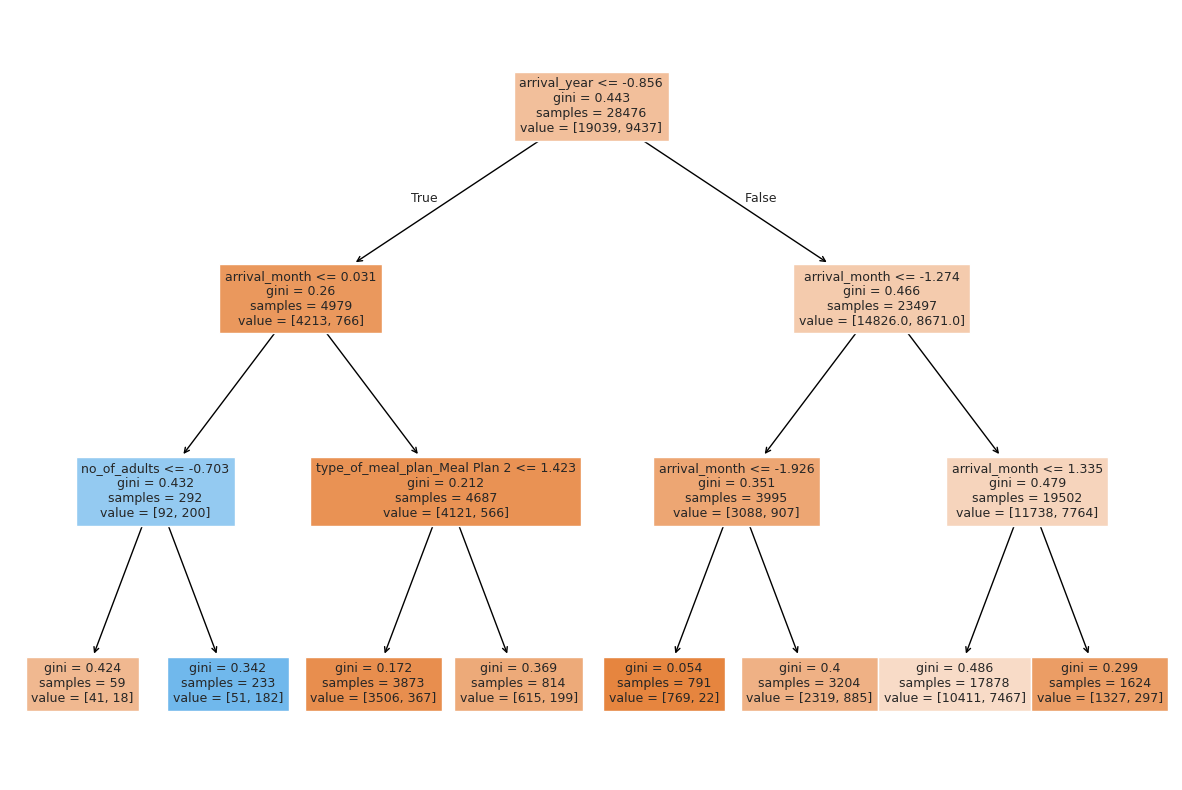

Accuracy: 0.666385728332631

Confusion Matrix:
 [[4706   15]
 [2360   38]]

Classification Report:
               precision    recall  f1-score   support

           0       0.67      1.00      0.80      4721
           1       0.72      0.02      0.03      2398

    accuracy                           0.67      7119
   macro avg       0.69      0.51      0.41      7119
weighted avg       0.68      0.67      0.54      7119



In [ ]:
#Initialize model
dt_model = DecisionTreeClassifier(max_depth = 3, random_state = 42)

#Train model
dt_model.fit(X_train, Y_train)

from sklearn import tree

#Visualization
plt.figure(figsize=(15,10))
out = tree.plot_tree(
    dt_model,
    feature_names = X_train.columns,
    filled = True,
    fontsize = 9
)

#Fixing arrows
for o in out:
  arrow = o.arrow_patch
  if arrow is not None:
    arrow.set_edgecolor('black')
    arrow.set_linewidth(1)

plt.show()

#Predictions
Y_pred_dt = dt_model.predict(X_test)

#Evaluation
print("Accuracy:", accuracy_score(Y_test, Y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred_dt))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_dt))

###Observation:
- The model achieves an overall accuracy of ~66.6%, which is comparable to Logistic Regression but does not indicate strong predictive performance.
- The tree structure shows that arrival year and arrival month are the most important features, as they appear at the top splits, indicating strong influence on booking cancellations.
- Other features such as number of adults and meal plan type also contribute to decision-making but at lower levels of the tree.
- From the confusion matrix, the model correctly predicts most non-cancelled bookings (class 0) but performs poorly in identifying cancelled bookings (class 1).
- The classification report indicates:
   * High recall for non-cancellations → model is biased towards predicting bookings as not cancelled.
   * High recall for non-cancellations → model is biased towards predicting bookings as not cancelled.
   * Extremely low recall for cancellations → very few actual cancellations are correctly identified.

- This suggests that the Decision Tree model is overly conservative and fails to capture patterns associated with cancellations effectively.

##Insights on tuned model performance across different metrics

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

#Define model
dt = DecisionTreeClassifier(random_state=42)

#Define hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

#Grid Search
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

#Fit tuned model
grid_search.fit(X_train, Y_train)

#Best model
best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

#Predictions
Y_pred = best_model.predict(X_test)

#Accuracy
accuracy = accuracy_score(Y_test, Y_pred)

#Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred)

#Classification Report
report = classification_report(Y_test, Y_pred)

#ROC AUC score
roc_auc = roc_auc_score(Y_test, best_model.predict_proba(X_test)[:,1])

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", report)
print("ROC-AUC Score:", roc_auc)

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}
Accuracy: 0.6957437842393595
Confusion Matrix:
 [[4511  210]
 [1956  442]]
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.96      0.81      4721
           1       0.68      0.18      0.29      2398

    accuracy                           0.70      7119
   macro avg       0.69      0.57      0.55      7119
weighted avg       0.69      0.70      0.63      7119

ROC-AUC Score: 0.7426894437732212
Precision: 0.6779141104294478
Recall: 0.18432026688907424
F1 Score: 0.2898360655737705


- After hyperparameter tuning, the Decision Tree model shows an accuracy of 69.6%, indicating a stable and reasonably good overall predictive performance.
- The precision value of 0.678 indicates that when the model predicts a booking will be canceled, it is correct about 67.8% of the time, showing improved reliability of positive predictions.
- The recall value of 18.4% suggests that the tuned model is able to identify some canceled bookings, but still misses a significant portion of actual cancellations.
- The F1-score of 0.29 indicates a moderate balance between precision and recall, showing improvement compared to Logistic Regression but lower performance compared to the base Decision Tree model.
- The ROC-AUC score of 0.743 indicates that the tuned model has a good ability to distinguish between canceled and non-canceled bookings across different probability thresholds.
- Hyperparameter tuning helped in improving model generalization and prediction stability, reducing the chances of overfitting.
- Overall, the tuned model demonstrates improved precision and balanced performance, but recall for canceled bookings remains relatively low, indicating scope for further improvement.

#Model Performance Comparison & Final Model Selection

##Comparison of the models

In [299]:
#Training Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, Y_train)

#Logistic Regression predictions (statsmodels)
y_pred_prob_lr = logit_model.predict(X_test_sm)
y_pred_lr = (y_pred_prob_lr >= 0.5).astype(int)

#Decision Tree predictions
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

#Tuned Decision Tree predictions
y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:,1]


#Storing results
results = [

    ["Logistic Regression",
     accuracy_score(Y_test, y_pred_lr),
     precision_score(Y_test, y_pred_lr),
     recall_score(Y_test, y_pred_lr),
     f1_score(Y_test, y_pred_lr),
     roc_auc_score(Y_test, y_pred_prob_lr)],


    ["Decision Tree",
     accuracy_score(Y_test, y_pred_dt),
     precision_score(Y_test, y_pred_dt),
     recall_score(Y_test, y_pred_dt),
     f1_score(Y_test, y_pred_dt),
     roc_auc_score(Y_test, y_prob_dt)],


    ["Tuned Decision Tree",
     accuracy_score(Y_test, y_pred_tuned),
     precision_score(Y_test, y_pred_tuned),
     recall_score(Y_test, y_pred_tuned),
     f1_score(Y_test, y_pred_tuned),
     roc_auc_score(Y_test, y_prob_tuned)]

]


#Comparison table
comparison_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
)

print(comparison_df.round(3))

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression     0.671      0.566   0.100     0.170    0.655
1        Decision Tree     0.756      0.663   0.562     0.608    0.780
2  Tuned Decision Tree     0.696      0.678   0.184     0.290    0.743


Looking at the models, we can conclude the following:
- The Decision Tree model achieved the highest accuracy of 75.6%, indicating that it correctly predicts the largest proportion of booking outcomes among all models.
- The Decision Tree model also shows the highest recall value of 56.2%, meaning it is significantly better at identifying actual booking cancellations compared to the other models.
- The F1-score of 0.608 for the Decision Tree indicates a good balance between precision and recall, making it the most effective model in detecting cancellations.
- The ROC-AUC score of 0.780 for the Decision Tree suggests strong capability in distinguishing between canceled and non-canceled bookings across different threshold values.
- The Logistic Regression model shows lower recall (10%) and F1-score (0.17), indicating that it struggles to correctly identify canceled bookings despite moderate overall accuracy.
- The Tuned Decision Tree model shows improvement over Logistic Regression in terms of precision (0.678) and ROC-AUC (0.743), but its recall (18.4%) is significantly lower than the base Decision Tree model.
- Overall, the Decision Tree model performs best across most evaluation metrics, particularly in identifying canceled bookings, which is critical for business decision-making.

Based on the comparison, the Decision Tree model is the most suitable model for predicting booking cancellations, as it provides better predictive performance and improved balance between precision and recall.

#Insights and Recommendations
- **Focus on high risk booking periods:** Arrival month and year were found to significantly influence cancellations. Hotels should implement stricter cancellation policies or advance payment requirements during high-risk periods.
- **Target customers with higher cancellation probability:** Customers with certain characteristics (e.g., specific meal plans, fewer adults, or certain booking patterns) show higher likelihood of cancellation. Personalized reminders or confirmation calls can help reduce cancellations.
- **Encourage committed bookings:** Since many cancellations are not being effectively predicted, offering discounts for non-refundable bookings or incentives for early payment can improve booking commitment.
- **Improve cancellation prediction systems:** Both models showed low recall for cancellations, indicating difficulty in identifying actual cancellations. This suggests a need for better features, additional data, or advanced models (e.g., ensemble methods).
- **Address class imbalance:** The poor performance in detecting cancellations indicates that cancelled bookings are underrepresented. Techniques like resampling (SMOTE) or class weighting can improve model performance.
- **Implement dynamic pricing strategies:** Based on predicted cancellation risk, hotels can adjust pricing or overbooking strategies to minimize revenue loss.
- **use model insights for operational planning:** Understanding cancellation patterns can help in better room allocation, staffing, and inventory management.

###Conclusion:
The analysis shows that while both Logistic Regression and Decision Tree models provide moderate predictive performance, they struggle to accurately identify cancelled bookings. Logistic Regression performs slightly better due to its more balanced performance across metrics. However, the low recall for cancellations highlights the need for further model improvement and better data handling. Overall, combining predictive modeling with strategic business actions can significantly reduce the impact of booking cancellations and improve operational efficiency.